<a href="https://colab.research.google.com/github/rll/deepul/blob/master/homeworks/hw4/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started

## Overview
This semester, all homeworks will be conducted through Google Colab notebooks. All code for the homework assignment will be written and run in this notebook. Running in Colab will automatically provide a GPU, but you may also run this notebook locally by following [these instructions](https://research.google.com/colaboratory/local-runtimes.html) if you wish to use your own GPU.

You will save images in the notebooks to use and fill out a given LaTeX template which will be submitted to Gradescope, along with your notebook code.

## Using Colab
On the left-hand side, you can click the different icons to see a Table of Contents of the assignment, as well as local files accessible through the notebook.

Make sure to go to **Runtime -> Change runtime type** and select **GPU** as the hardware accelerator. This allows you to use a GPU. Run the cells below to get started on the assignment. Note that a session is open for a maximum of 12 hours, and using too much GPU compute may result in restricted access for a short period of time. Please start the homework early so you have ample time to work.

**If you loaded this notebook from clicking "Open in Colab" from github, you will need to save it to your own Google Drive to keep your work.**

## General Tips
In each homework problem, you will implement and train various diffusion models.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

After you complete the assignment, download all of the images outputted in the results/ folder and upload them to the figure folder in the given latex template.

Run the cells below to download and load up the starter code.

In [1]:
from google.colab import userdata

import os, subprocess, re
# Install and start OpenSSH
os.system("apt-get -qq update && apt-get -qq install -y openssh-server")
os.makedirs("/root/.ssh", exist_ok=True)
open("/root/.ssh/authorized_keys","w").write(userdata.get('pubkey')+"\n")
os.system("chmod 700 /root/.ssh && chmod 600 /root/.ssh/authorized_keys")
os.system("sed -i 's/^#\\?PasswordAuthentication .*/PasswordAuthentication no/' /etc/ssh/sshd_config")
os.system("service ssh restart || service ssh start")

# Install ngrok tunnel
os.system("pip -q install pyngrok")
from pyngrok import ngrok
ngrok.set_auth_token(userdata.get('NGROK_TOKEN'))
t = ngrok.connect(22, "tcp")
split = t.public_url.split(':')

print(f'Hostname: {split[1]}')
print(f'Port: {split[2]}')

Hostname: //4.tcp.ngrok.io
Port: 17660


In [2]:
!git clone https://github.com/rll/deepul.git
!pip install ./deepul

Cloning into 'deepul'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 270 (delta 51), reused 32 (delta 32), pack-reused 188 (from 2)
Receiving objects: 100% (270/270), 94.71 MiB | 26.11 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Processing ./deepul
  Preparing metadata (setup.py) ... done
  Created wheel for deepul: filename=deepul-0.1.0-py3-none-any.whl size=22739 sha256=cb6604b2a154bf390ca9f64fc1fbefe588b5d0745e8c27c19cd5d0f18298c1a6
  Stored in directory: /tmp/pip-ephem-wheel-cache-jf60qnv1/wheels/ef/ca/e6/838f85393ab50f0d590acc4f5cfa805863e523ebaee1b400c4
Successfully built deepul


In [3]:
import warnings

warnings.filterwarnings('ignore')
from deepul.hw4_helper import *

import importlib
from dataclasses import dataclass

import torch
from torch.utils.data import DataLoader
import torch.optim as optim

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.mps.is_available()
    else 'cpu'
)

torch.set_default_device(device)
print(f'{device=}')

from diffusion import *
from train import *

device='cuda'


# Question 1: Toy Dataset [30pt]

In this question, we will train a simple diffusion models a toy 2D dataset.

Execute the cell below to visualize our datasets.

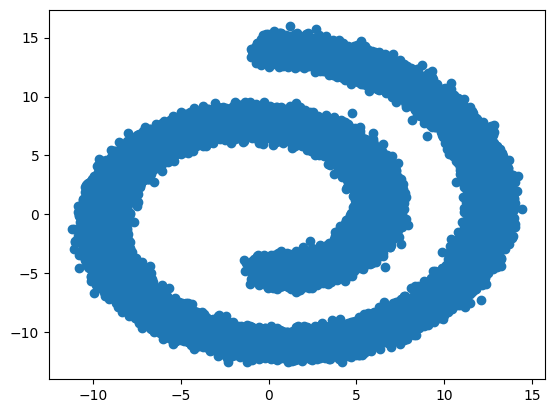

In [4]:
visualize_q1_dataset()

For code simplicity, we will train a continuous-time variant of the diffusion prompt. In practice training objectives and code between discrete-time and continuous-time diffusion models are similar.

Given a data element $x$ and neural net $f_\theta(x, t)$, implement the following diffusion training steps:
1. Sample the diffusion timestep: $t \sim \text{Uniform}(0, 1)$
2. Compute the noise-strength following a cosine schedule: $\alpha_t = \cos\left(\frac{\pi}{2}t\right), \sigma_t = \sin\left(\frac{\pi}{2}t\right)$
3. Apply the forward process - Sample noise $\epsilon \sim N(0,I)$ (same shape as $x$) and compute noised $x_t = \alpha_t x + \sigma_t \epsilon$
4. Estimate $\hat{\epsilon} = f_\theta(x_t, t)$
5. Optimize the loss $L = \lVert \epsilon - \hat{\epsilon} \rVert_2^2$. Here, it suffices to just take the mean over all dimensions.

Note that for the case of continuous-time diffusion, the forward process is $x_{0\to1}$ and reverse process is $x_{1\to0}$

Use an MLP for $f_\theta$ to optimize the loss. You may find the following details helpful.
* Normalize the data using mean and std computed from the train dataset
* Train 100 epochs, batch size 1024, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* MLP with 4 hidden layers and hidden size 64
* Condition on t by concatenating it with input x (i.e. 2D x + 1D t = 3D cat(x, t))

To sample, implement the standard DDPM sampler. You may find the equation from the [DDIM paper](https://arxiv.org/pdf/2010.02502.pdf) helpful, rewritten and re-formatted here for convenience.
$$x_{t-1} = \alpha_{t-1}\left(\frac{x_t - \sigma_t\hat{\epsilon}}{\alpha_t}\right) + \sqrt{\sigma_{t-1}^2 - \eta_t^2}\hat{\epsilon} + \eta_t\epsilon_t$$
where $\epsilon_t \sim N(0, I)$ is random Gaussian noise. For DDPM, let
$$\eta_t = \sigma_{t-1}/\sigma_t\sqrt{1 - \alpha_t^2/\alpha_{t-1}^2}$$
To run the reverse process, start from $x_1 \sim N(0, I)$ and perform `num_steps` DDPM updates (a hyperparameter), pseudocode below.
```
ts = linspace(1 - 1e-4, 1e-4, num_steps + 1)
x = sample_normal
for i in range(num_steps):
    t = ts[i]
    tm1 = ts[i + 1]
    eps_hat = model(x, t)
    x = DDPM_UPDATE(x, eps_hat, t, tm1)
return x
```
Note: If you encounter NaNs, you may need to clip $\sigma_{t-1}^2 - \eta_t^2$ to 0 if it goes negative, as machine precision issues can make it a very small negative number (e.g. -1e-12) if its too close to 0

In [9]:
def q1(train_data, test_data):
    """
    train_data: A (100000, 2) numpy array of 2D points
    test_data: A (10000, 2) numpy array of 2D points

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """

    @dataclass
    class Config:
        num_epochs = 100
        batch_size = 1024
        lr = 1e-3
        warmup_iters = 100
        min_lr = 0
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        H = 64
        dropout = 0.0

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    data_mean, data_std = train_data.mean(0), train_data.std(0)
    train_data = (train_data - data_mean) / data_std
    test_data = (test_data - data_mean) / data_std

    model = ContinuousDiffusion(MLPConcat(Config.H), shape=(2,))
    optimizer = optim.Adam(model.parameters(), Config.lr)
    train_loader = DataLoader(train_data, Config.batch_size, shuffle=True, generator=torch.Generator(device=device))
    test_loader = DataLoader(test_data, Config.batch_size, shuffle=False, generator=torch.Generator(device=device))

    train_losses, test_losses = train(model, optimizer, train_loader, test_loader, Config.num_epochs, dtype=Config.dtype, lr_scheduler=lr_scheduler)

    num_samples_list = 2**torch.linspace(0, 9, 9).to(torch.int)
    all_samples = torch.stack([model.generate(2000, num_steps) for num_steps in num_samples_list], dim=0)
    all_samples = data_std * all_samples.cpu().numpy() + data_mean

    return train_losses, test_losses, all_samples

initial loss: 1.0107925295829774
epoch 1: 0.5710115969181061
epoch 2: 0.4653890460729599
epoch 3: 0.46187181770801544
epoch 4: 0.46666734516620634
epoch 5: 0.4588444471359253
epoch 6: 0.46287807524204255
epoch 7: 0.4695067673921585
epoch 8: 0.46124023497104644
epoch 9: 0.444953528046608
epoch 10: 0.45379557013511657
epoch 11: 0.4589580655097961
epoch 12: 0.44825237691402436
epoch 13: 0.4535871684551239
epoch 14: 0.45812163054943084
epoch 15: 0.44371306598186494
epoch 16: 0.4452936738729477
epoch 17: 0.44596078991889954
epoch 18: 0.4345145136117935
epoch 19: 0.446202552318573
epoch 20: 0.44475623965263367
epoch 21: 0.44739755392074587
epoch 22: 0.45288510620594025
epoch 23: 0.45015559494495394
epoch 24: 0.4422564685344696
epoch 25: 0.4221062511205673
epoch 26: 0.43648613095283506
epoch 27: 0.43004330396652224
epoch 28: 0.43863320648670195
epoch 29: 0.43985241651535034
epoch 30: 0.43451849520206454
epoch 31: 0.43530540764331815
epoch 32: 0.43565419912338255
epoch 33: 0.4410677313804626
e

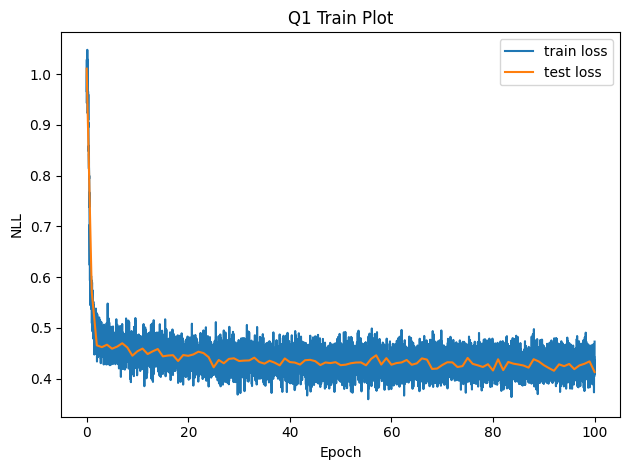

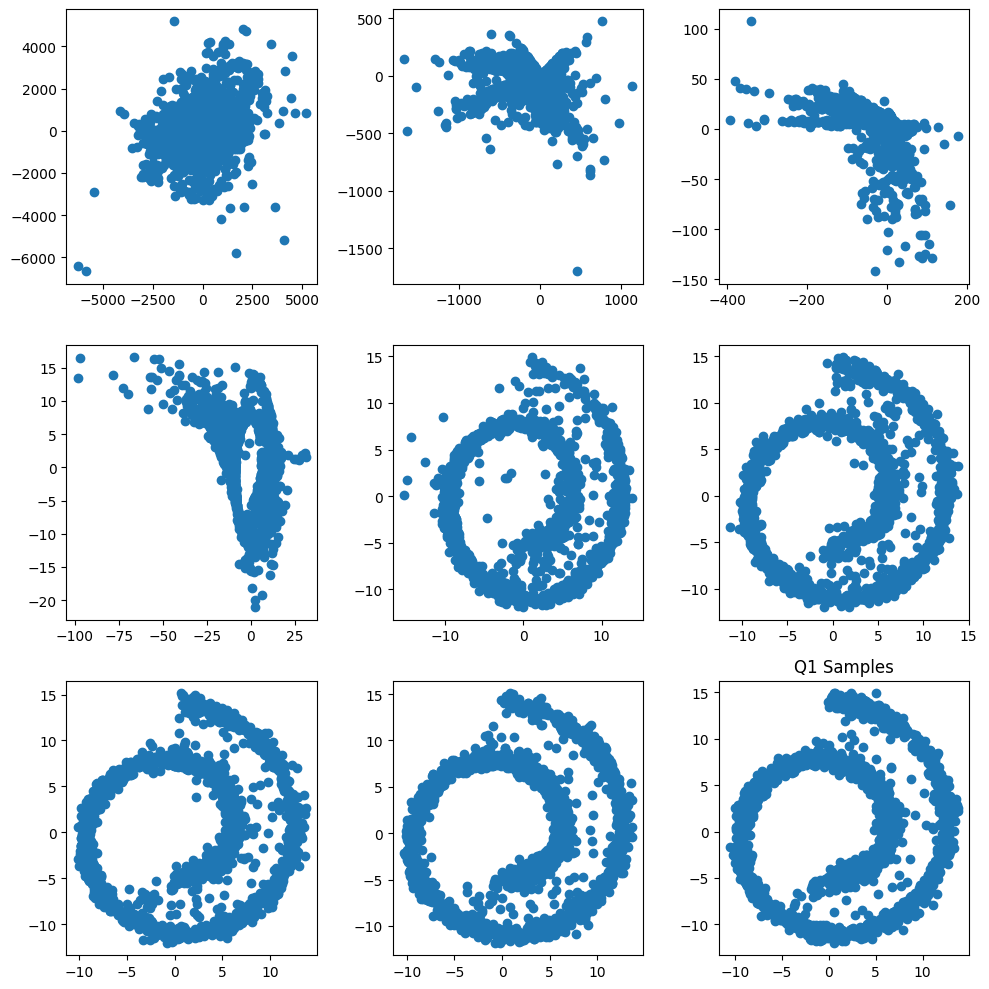

In [ ]:
q1_save_results(q1)

# Question 2: Pixel-Space Diffusion on CIFAR-10 [30pt]

In this question, we will train pixel-space UNet diffusion model on CIFAR-10

Execute the cell below to visualize our datasets.

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


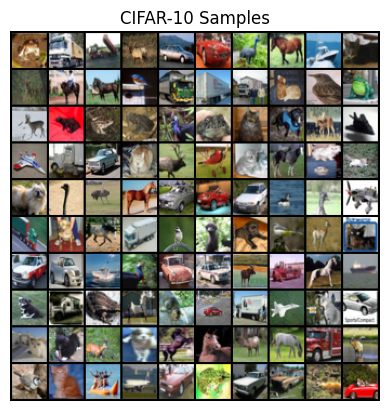

In [ ]:
visualize_q2_data()

We'll use a UNet architecture similar to the original [DDPM](https://arxiv.org/abs/2006.11239) paper. We provide the following pseudocode for each part of the model:
```
def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = np.exp(-np.log(max_period) * np.arange(0, half, dtype=float32) / half)
    args = timesteps[:, None].astype(float32) * freqs[None]
    embedding = cat([np.cos(args), np.sin(args)], axis=-1)
    if dim % 2:
        embedding = cat([embedding, np.zeros_like(embedding[:, :1])], axis=-1)
    return embedding

ResidualBlock(in_channels, out_channels, temb_channels)
    Given x, temb
    h = Conv2d(in_channels, out_channels, 3, padding=1)(x)
    h = GroupNorm(num_groups=8, num_channels=out_channels)(h)
    h = SiLU()(h)
    
    temb = Linear(temb_channels, out_channels)(temb)
    h += temb[:, :, None, None] # h is BxDxHxW, temb is BxDx1x1
    
    h = Conv2d(out_channels, out_channels, 3, padding=1)(h)
    h = GroupNorm(num_groups=8, num_channels=out_channels)(h)
    h = SiLU()(h)
    
    if in_channels != out_channels:
        x = Conv2d(in_channels, out_channels, 1)(x)
    return x + h
    
Downsample(in_channels)
    Given x
    return Conv2d(in_channels, in_channels, 3, stride=2, padding=1)(x)

Upsample(in_channels)
    Given x
    x = interpolate(x, scale_factor=2)
    x = Conv2d(in_channels, in_channels, 3, padding=1)(x)
    return x
    
UNet(in_channels, hidden_dims, blocks_per_dim)
    Given x, t
    temb_channels = hidden_dims[0] * 4
    emb = timestep_embedding(t, hidden_dims[0])
    emb = Sequential(Linear(hidden_dims[0], temb_channels), SiLU(), Linear(temb_channels, temb_channels))(emb)
    
    h = Conv2d(in_channels, hidden_dims[0], 3, padding=1)(x)
    hs = [h]
    prev_ch = hidden_dims[0]
    down_block_chans = [prev_ch]
    for i, hidden_dim in enumerate(hidden_dims):
        for _ in range(blocks_per_dim):
            h = ResidualBlock(prev_ch, hidden_dim, temb_channels)(h, emb)
            hs.append(h)
            prev_ch = hidden_dim
            down_block_chans.append(prev_ch)
        if i != len(hidden_dims) - 1:
            h = Downsample(prev_ch)(h)
            hs.append(h)
            down_block_chans.append(prev_ch)
    
    h = ResidualBlock(prev_ch, prev_ch, temb_channels)(h, emb)
    h = ResidualBlock(prev_ch, prev_ch, temb_channels)(h, emb)
    
    for i, hidden_dim in list(enumerate(hidden_dims))[::-1]:
        for j in range(blocks_per_dim + 1):
            dch = down_block_chans.pop()
            h = ResidualBlock(prev_ch + dch, hidden_dim, temb_channels)(cat(h, hs.pop()), emb)
            prev_ch = hidden_dim
            if i and j == blocks_per_dim:
                h = Upsample(prev_ch)(h)
    
    h = GroupNorm(num_groups=8, num_channels=prev_ch)(h)
    h = SiLU()(h)
    out = Conv2d(prev_ch, in_channels, 3, padding=1)(h)
    return out
```

**Hyperparameter details**
* Normalize data to [-1, 1]
* UNET with hidden_dims as [64, 128, 256, 512] and 2 blocks_per_dim
* Train 60 epochs, batch size 256, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* For diffusion schedule, sampling and loss, use the same setup as Q1

You may also find it helpful to clip $\hat{x} = \frac{x_t - \sigma_t \hat{\epsilon}}{\alpha_t}$ to [-1, 1] during each sampling step.

In [13]:
def q2(train_data, test_data):
    """
    train_data: A (50000, 32, 32, 3) numpy array of images in [0, 1]
    test_data: A (10000, 32, 32, 3) numpy array of images in [0, 1]

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 10 x 10 grid of generated samples. Each row represents 10 samples generated
      for a specific number of diffusion timesteps. Do this for 10 evenly logarithmically spaced integers
      1 to 512, i.e. np.power(2, np.linspace(0, 9, 10)).astype(int)
    """

    @dataclass
    class Config:
        # num_epochs = 60
        num_epochs = 1
        batch_size = 256
        lr = 1e-3
        warmup_iters = 100
        min_lr = 0
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        hidden_dims = [64, 128, 256, 512]
        blocks_per_dim = 2

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    train_data = 2 * train_data.astype(np.float32).transpose(0, 3, 1, 2) - 1
    test_data = 2 * test_data.astype(np.float32).transpose(0, 3, 1, 2) - 1

    model = ContinuousDiffusion(UNet(3, Config.hidden_dims, Config.blocks_per_dim), shape=(3, 32, 32), clip_bounds=(-1, 1))
    model = torch.compile(model)
    print('Done Compiling')
    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_data, batch_size=Config.batch_size, shuffle=True, generator=torch.Generator('cuda'))
    test_loader = DataLoader(test_data, batch_size=Config.batch_size, shuffle=False, generator=torch.Generator('cuda'))

    train_losses, test_losses = train(model, optimizer, train_loader, test_loader, Config.num_epochs, dtype=Config.dtype, lr_scheduler=lr_scheduler)

    samples = torch.empty(10, 10, 3, 32, 32)
    num_steps_list = 2**torch.linspace(0, 9, 10).to(torch.int)
    for i, num_steps in enumerate(num_steps_list):
        samples[i, :, :, :, :] = model.generate(10, num_steps)
    samples = (samples.permute(0, 1, 3, 4, 2).cpu().numpy() + 1) / 2

    torch.save(model.state_dict(), 'model_t1000.pth')

    return train_losses, test_losses, samples

Done Compiling
initial loss: 1.0967289000749587
epoch 1: 0.08896648958325386
epoch 2: 0.07795386351644992
epoch 3: 0.07423730082809925
epoch 4: 0.0689449249766767
epoch 5: 0.06840277658775448
epoch 6: 0.06860423665493727
epoch 7: 0.06752856504172086
epoch 8: 0.06541537838056684
epoch 9: 0.06481072884052992
epoch 10: 0.0661225157789886
epoch 11: 0.06772708622738718
epoch 12: 0.06624942589551211
epoch 13: 0.06400428367778659
epoch 14: 0.06733122244477271
epoch 15: 0.06457308428362012
epoch 16: 0.06640646895393729
epoch 17: 0.06642702352255583
epoch 18: 0.06584281139075757
epoch 19: 0.06616232823580503
epoch 20: 0.0638882115483284
epoch 21: 0.06332704741507769
epoch 22: 0.06326265195384621
epoch 23: 0.06459685135632753
epoch 24: 0.06393763963133096
epoch 25: 0.06515928748995066
epoch 26: 0.06181470705196261
epoch 27: 0.06335606565698981
epoch 28: 0.06306443177163601
epoch 29: 0.062769366055727
epoch 30: 0.06400051387026906
epoch 31: 0.0614360854960978
epoch 32: 0.06388766616582871
epoch 3

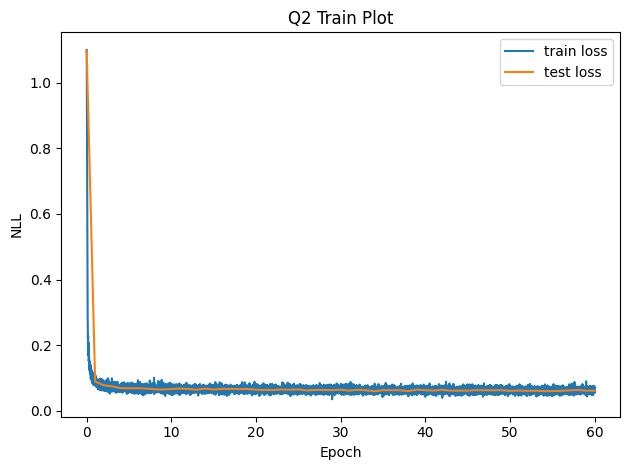

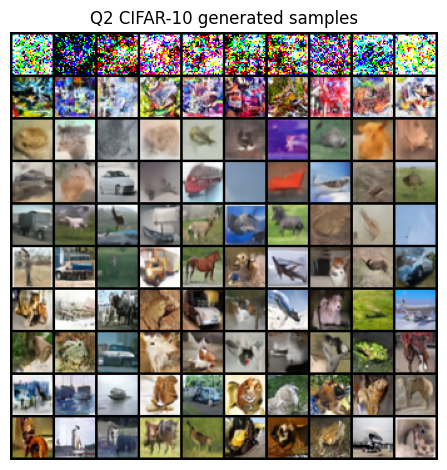

In [ ]:
q2_save_results(q2)

# Question 3: Class-Conditional Latent-Space Diffusion on CIFAR-10 with DiT [60pt]

In this question, we will train latent-space [Diffusion Transformer (DiT)](https://arxiv.org/abs/2212.09748) model on CIFAR-10 **with class conditioning.**

Execute the cell below to visualize our datasets.

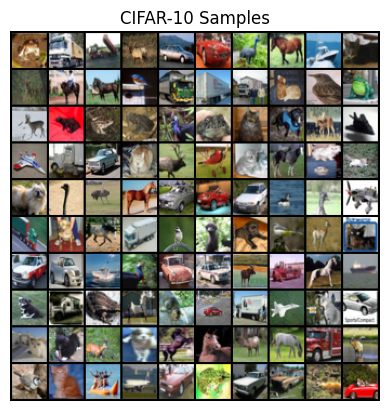

Labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1]


In [15]:
visualize_q3_data()

## Part 3(a) VAE reconstructions and Scale Factor [10pt]

Similar to how we learned a AR model in VQGAN latent space for homework 1, in this question, you will train a diffusion model in the latent space of a VAE. Note that since diffusion models can model continuous distributions, we do not need a discretization bottleneck in the VAE, and the latent space itself is continuous.

Below, we specify each of the relevant properties or functions that you may need.

In [ ]:
# @property
# def latent_shape(self) -> Tuple[int, int, int]:
#     """Size of the encoded representation"""
#
# def encode(self, x: np.ndarray) -> np.ndarray:
#     """Encode an image x. Note: Channel dim is in dim 1
#
#     Args:
#         x (np.ndarray, dtype=float32): Image to encode. shape=(batch_size, 3, 32, 32). Values in [-1, 1]
#
#     Returns:
#         np.ndarray: Encoded image. shape=(batch_size, 4, 8, 8). Unbounded values
#     """
#
# def decode(self, z: np.ndarray) -> np.ndarray:
#     """Decode an encoded image.
#
#     Args:
#         z (np.ndarray, dtype=float32): Encoded image. shape=(batch_size, 4, 8, 8). Unbounded values.
#
#     Returns:
#         np.ndarray: Decoded image. shape=(batch_size, 3, 32, 32). Values in [-1, 1]
#     """
#

In this part, feed the given images through the VAE to compute and visualize reconstructions. In addition, you will compute a scale factor that will be needed during diffusion training to help normalize the data.

To estimate the scale factor, encode 1000 images into the VAE latent space, flatten the entire tensor along all dimensions, and compute the standard deviation.

In [18]:
# patch this function since we are using default cuda device which is not expected in the deepul library
def q3a_save_results(fn):
    train_data, _ = load_q3_data()
    train_images = train_data.data / 255.0
    idxs = torch.randint(0, len(train_images), (1000,), device='cpu')  # explicitly use cpu to avoid default cuda device
    images = train_images[idxs]
    vae = load_pretrain_vae()

    recons, scale_factor = fn(images, vae)
    recons = recons.reshape(-1, *recons.shape[2:])
    show_samples(recons * 255.0, fname="results/q3_a_reconstructions.png", title=f"Q3(a) CIFAR-10 VAE Reconstructions")
    print(f"Scale factor: {scale_factor:.4f}")

In [19]:
def q3_a(images, vae):
    """
    images: (1000, 32, 32, 3) numpy array in [0, 1], the images to pass through the encoder and decoder of the vae
    vae: a vae model, trained on the relevant dataset

    Returns
    - a numpy array of size (50, 2, 32, 32, 3) of the decoded image in [0, 1] consisting of pairs
      of real and reconstructed images
    - a float that is the scale factor
    """
    images = 2 * images.transpose(0, 3, 1, 2) - 1
    latents = vae.encode(images)
    reconstructions = vae.decode(latents[:50]).cpu().numpy()
    autoencoded_images =  1/2 * (1 + np.moveaxis(np.stack((images[:50], reconstructions), axis=1), 2, -1))
    scale_factor = latents.std().item()

    return autoencoded_images, scale_factor

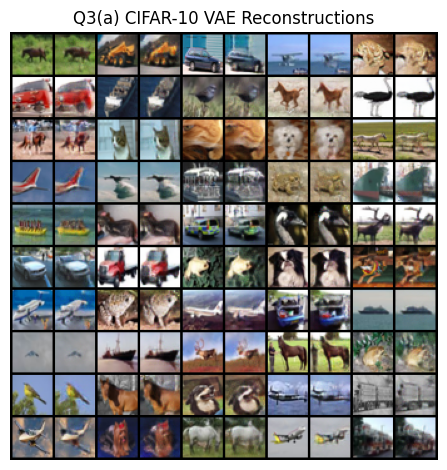

Scale factor: 1.2821


In [20]:
q3a_save_results(q3_a)

## Part 3(b) Diffusion Transformer [30pt]
In this part, you will train a Diffusion Transformer (Dit) on the latent space of the above pretrained VAE. You can use your Transformer implementation from HW1 as the core part of the DiT implementation.

Below, we outline the key modifications needed on top of the standard Transformer for DiT.
```
def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    return pos_embed

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

DiTBlock(hidden_size, num_heads)
    Given x (B x L x D), c (B x D)
    c = SiLU()(c)
    c = Linear(hidden_size, 6 * hidden_size)(c)
    shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = c.chunk(6, dim=1)
    
    h = LayerNorm(hidden_size, elementwise_affine=False)(x)
    h = modulate(h, shift_msa, scale_msa)
    x = x + gate_msa.unsqueeze(1) * Attention(hidden_size, num_heads)(h)
    
    h = LayerNorm(hidden_size, elementwise_affine=False)(x)
    h = modulate(h, shift_mlp, scale_mlp)
    x = x + gate_mlp.unsqueeze(1) * MLP(hidden_size)(h)
    
    return x
    
FinalLayer(hidden_size, patch_size, out_channels)
    Given x (B x L x D), c (B x D)
    c = SiLU()(c)
    c = Linear(hidden_size, 2 * hidden_size)(c)
    shift, scale = c.chunk(2, dim=1)
    x = LayerNorm(hidden_size, elementwise_affine=False)(x)
    x = modulate(x, shift, scale)
    x = Linear(hidden_size, patch_size * patch_size * out_channels)(x)
    return x
    
DiT(input_shape, patch_size, hidden_size, num_heads, num_layers, num_classes, cfg_dropout_prob)
    Given x (B x C x H x W) - image, y (B) - class label, t (B) - diffusion timestep
    x = patchify_flatten(x) # B x C x H x W -> B x (H // P * W // P) x D, P is patch_size
    x += pos_embed # see get_2d_sincos_pos_embed
    
    t = compute_timestep_embedding(t) # Same as in UNet
    if training:
        y = dropout_classes(y, cfg_dropout_prob) # Randomly dropout to train unconditional image generation
    y = Embedding(num_classes + 1, hidden_size)(y)
    c = t + y
    
    for _ in range(num_layers):
        x = DiTBlock(hidden_size, num_heads)(x, c)
    
    x = FinalLayer(hidden_size, patch_size, out_channels)(x)
    x = unpatchify(x) # B x (H // P * W // P) x (P * P * C) -> B x C x H x W
    return x
```

**Hyperparameter details**
* Normalize image to [-1, 1], (2) Encode using the VAE, (3) divide latents by the scale_factor compute in part (a)
* Transformer with patch_size 2, hidden_size 512, num_heads 8, num_layers 12
* Train 60 epochs, batch size 256, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* When sampling, remember to multiple the final generated latents by the scale_factor before feeding it through the decoder
* For diffusion schedule, sampling and loss, use the same setup as Q1

For class conditioning, learn an embedding for each class, and an extra embedding to represent the null class. To condition, add the class embedding to the timestep embedding before feeding it into the transformer blocks (see pseudocode). **Train your class conditional diffusion models while dropping out the class (replace with null class) 10% of the time. This will be necessary for part (c).**

**Remember to save your model parameters after training, as you will need them for part (c)**

In [ ]:
import math
from torch.utils.data import TensorDataset

def forward_in_batches(forward, data, batch_size):
    num_batches = math.ceil(data.shape[0] / batch_size)
    return torch.cat([
        forward(data[i*batch_size:(i+1)*batch_size]) for i in range(num_batches)
    ], dim=0)

def get_samples(model, num_steps=512, samples_per_class=10, num_classes=10, cfg_scale=1):
    num_samples = samples_per_class * num_classes
    class_idxs = torch.tensor([
        class_idx
        for class_idx in range(num_classes)
        for _ in range(samples_per_class)
    ])
    return model.generate(num_samples, num_steps, class_idxs, cfg_scale)

In [ ]:
def q3_b(train_data, train_labels, test_data, test_labels, vae):
    """
    train_data: A (50000, 32, 32, 3) numpy array of images in [0, 1]
    train_labels: A (50000,) numpy array of class labels
    test_data: A (10000, 32, 32, 3) numpy array of images in [0, 1]
    test_labels: A (10000,) numpy array of class labels
    vae: a pretrained VAE

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 10 x 10 grid of generated samples. Each row represents 10 samples generated
      for a specific class (i.e. row 0 is class 0, row 1 class 1, ...). Use 512 diffusion timesteps
    """
    """ YOUR CODE HERE """
    @dataclass
    class Config:
        num_epochs = 60
        batch_size = 256
        lr = 1e-3
        warmup_iters = 100
        min_lr = 0
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.float32

        patch_size = 2
        hidden_size = 512
        num_heads = 8
        num_layers = 12
        dropout_prob = 0.1
        SCALE_FACTOR = 1.2586

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    train_data = 2 * train_data.astype(np.float32).transpose(0, 3, 1, 2) - 1
    test_data = 2 * test_data.astype(np.float32).transpose(0, 3, 1, 2) - 1

    train_latents = forward_in_batches(vae.encode, train_data, Config.batch_size) / Config.SCALE_FACTOR
    test_latents = forward_in_batches(vae.encode, test_data, Config.batch_size) / Config.SCALE_FACTOR
    print('Computed Latents')


    input_shape = train_latents.shape[1:]
    num_classes = train_labels.max().item() + 1
    print(f'{num_classes=}')

    net = DiT(
        input_shape,
        Config.patch_size,
        Config.hidden_size,
        Config.num_heads,
        Config.num_layers,
        num_classes,
        Config.dropout_prob
    )

    model = ContinuousDiffusion(net, input_shape)
    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(
        TensorDataset(train_latents, torch.tensor(train_labels)),
        batch_size=Config.batch_size, shuffle=True, generator=torch.Generator(device)
    )
    test_loader = DataLoader(
        TensorDataset(test_latents, torch.tensor(test_labels)),
        batch_size=Config.batch_size, shuffle=False, generator=torch.Generator(device)
    )

    train_losses, test_losses = train(
        model,
        optimizer,
        train_loader,
        test_loader,
        Config.num_epochs,
        dtype=Config.dtype,
        lr_scheduler=lr_scheduler
    )

    # get samples
    gen_latents = get_samples(model)
    samples = vae.decode(Config.SCALE_FACTOR * gen_latents)
    samples = (samples + 1) / 2
    samples = samples.cpu().numpy().transpose(0, 2, 3, 1).reshape(10, 10, 32, 32, 3)

    # save model
    torch.save(model.state_dict(), 'q3b.pth')

    return train_losses, test_losses, samples

Computed Latents
num_classes=10
initial loss: 1.3461052387952805
epoch 1: 0.43015789017081263
epoch 2: 0.41947921365499496
epoch 3: 0.41321084424853327
epoch 4: 0.4110389672219753
epoch 5: 0.4033912941813469
epoch 6: 0.40052090361714365
epoch 7: 0.39027861803770064
epoch 8: 0.39923510402441026
epoch 9: 0.39114764556288717
epoch 10: 0.3946727253496647
epoch 11: 0.39058207124471667
epoch 12: 0.38764865398406984
epoch 13: 0.38644378036260607
epoch 14: 0.3862825110554695
epoch 15: 0.38645540326833727
epoch 16: 0.3848507709801197
epoch 17: 0.38856673538684844
epoch 18: 0.3843023419380188
epoch 19: 0.38951543122529986
epoch 20: 0.3790748730301857
epoch 21: 0.3843119882047176
epoch 22: 0.37400637567043304
epoch 23: 0.37954683005809786
epoch 24: 0.3790379285812378
epoch 25: 0.379053458571434
epoch 26: 0.381371533870697
epoch 27: 0.38180127143859866
epoch 28: 0.38092771619558335
epoch 29: 0.36903784051537514
epoch 30: 0.3738911345601082
epoch 31: 0.37630462273955345
epoch 32: 0.3738013513386249

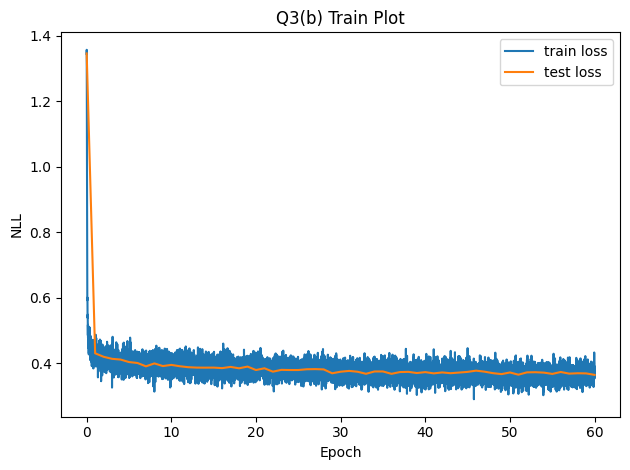

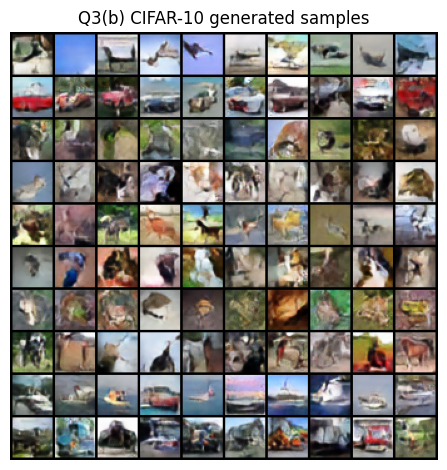

In [ ]:
q3b_save_results(q3_b)

In [ ]:
input_shape = (4, 8, 8)
patch_size = 2
hidden_size = 512
num_heads = 8
num_layers = 12
dropout_prob = 0.1
num_classes = 10
SCALE_FACTOR = 1.2586

net = DiT(input_shape, patch_size, hidden_size, num_heads, num_layers, num_classes, dropout_prob)
model = ContinuousDiffusion(net, input_shape)
model.load_state_dict(torch.load('q3b.pth'))
vae = load_pretrain_vae()

In [ ]:
model.eval()
gen_latents = model.generate(100, 512, class_idxs=torch.tensor([1] * 100))
samples = vae.decode(SCALE_FACTOR * gen_latents)
samples = (samples + 1) / 2
samples = samples.cpu().numpy().transpose(0, 2, 3, 1)

## Part 3(c) Classifier-Free Guidance [20pt]
In this part, you will implement [Classifier-Free Guidance](https://arxiv.org/abs/2207.12598) (CFG). CFG is a widely used method during diffusion model sampling to push samples towards more accurately aligning with the conditioning information (e.g. class, text caption).

Implement CFG requires a small modification to the diffusion sampling code. Given a CIFAR-10 class label, instead of using $\hat{\epsilon} = f_\theta(x_t, t, y)$ to sample, use:
$$\hat{\epsilon} = f_\theta(x_t, t, \varnothing) + w(f_\theta(x_t, t, y) - f_\theta(x_t, t, \varnothing))$$
where $w$ is a sampling hyperparameter that controls the strength of CFG. $\varnothing$ indicates the unconditional model with the class label dropped out, which your pre-trained UNet from 3(b) should support. Note that $w = 1$ recovers standard sampling.

Note: It may be expected to see worse samples (e.g. sautrated images) when CFG value is too high. Generation quality is closer to a U-shape when increasing CFG values (gets better, then worse)

In [ ]:
def q3_c(vae):
    """
    vae: a pretrained vae

    Returns
    - a numpy array of size (4, 10, 10, 32, 32, 3) of samples in [0, 1] drawn from your model.
      The array represents a 4 x 10 x 10 grid of generated samples - 4 10 x 10 grid of samples
      with 4 different CFG values of w = {1.0, 3.0, 5.0, 7.5}. Each row of the 10 x 10 grid
      should contain samples of a different class. Use 512 diffusion sampling timesteps.
    """
    """ YOUR CODE HERE """
    @dataclass
    class Config:
        input_shape = (4, 8, 8)
        patch_size = 2
        hidden_size = 512
        num_heads = 8
        num_layers = 12
        dropout_prob = 0.1
        num_classes = 10
        SCALE_FACTOR = 1.2586

    net = DiT(
        Config.input_shape,
        Config.patch_size,
        Config.hidden_size,
        Config.num_heads,
        Config.num_layers,
        Config.num_classes,
        Config.dropout_prob
    )

    model = ContinuousDiffusion(net, Config.input_shape)
    model.load_state_dict(torch.load('q3b.pth'))


    # get samples
    cfg_scales = [1.0, 3.0, 5.0, 7.5]
    gen_latents = torch.cat([
        get_samples(model, cfg_scale=cfg_scale)
        for cfg_scale in cfg_scales
    ])

    samples = vae.decode(Config.SCALE_FACTOR * gen_latents)
    samples = (samples + 1) / 2
    samples = samples.cpu().numpy().transpose(0, 2, 3, 1).reshape(4, 10, 10, 32, 32, 3)

    return samples

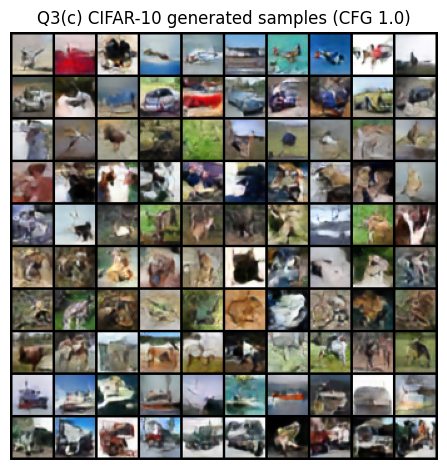

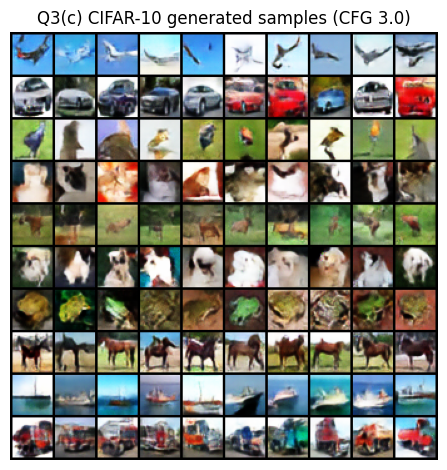

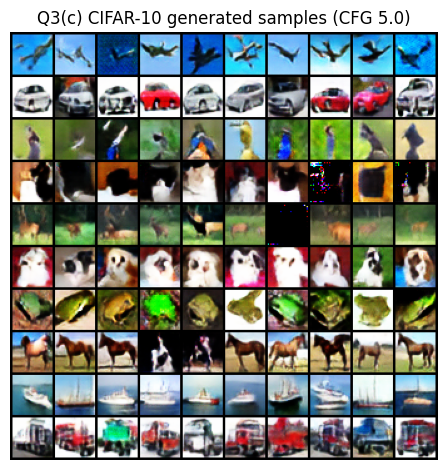

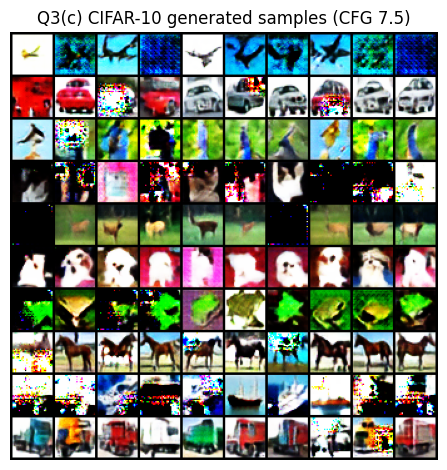

In [ ]:
q3c_save_results(q3_c)